# CineMatch — Stage 1: Data Exploration and Preprocessing

Welcome to the first stage of **CineMatch**! In this notebook, we will set up the data pipeline, download the datasets (MovieLens for movies and a slice of Goodbooks-10k for books), clean them, perform Exploratory Data Analysis (EDA), and establish our user-aware temporal/random split evaluation strategy.

Let's import our libraries and configure the environment.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure our src files are in the python path
sys.path.append(os.path.abspath(".."))

from src.data.dataset import DatasetManager
from src.data.preprocessing import DataPreprocessor

%matplotlib inline
plt.style.use('ggplot')
print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Download and Prepare Datasets

We use `DatasetManager` to fetch:
1. **MovieLens latest small dataset** (~100k ratings, 9k movies).
2. **Goodbooks-10k dataset** (sliced to users <= 2000 for local efficiency, resulting in ~100k ratings, 10k books).

In [2]:
# Initialize managers (using '../data' as relative data directory)
manager = DatasetManager(data_dir="../data")
preprocessor = DataPreprocessor(data_dir="../data")

print("Preparing MovieLens dataset...")
try:
    if not manager.prepare_movielens():
        print("MovieLens download failed, generating fallback data.")
        manager.generate_fallback_data()
except Exception as e:
    print(f"Error preparing MovieLens: {e}. Generating fallback data.")
    manager.generate_fallback_data()

print("Preparing Goodreads dataset...")
try:
    if manager.prepare_goodbooks():
        manager.create_book_subset(user_limit=2000)
    else:
        print("Goodreads download failed, generating fallback data.")
        manager.generate_fallback_data()
except Exception as e:
    print(f"Error preparing Goodreads: {e}. Generating fallback data.")
    manager.generate_fallback_data()

print("All datasets downloaded and cached.")

2026-08-22 13:33:44,889 - INFO - File already exists: C:\Users\ASUS\.gemini\antigravity\scratch\cinematch\data\raw\ml-latest-small.zip. Skipping download.


2026-08-22 13:33:44,890 - INFO - MovieLens dataset is ready in raw folder.


2026-08-22 13:33:44,891 - INFO - File already exists: C:\Users\ASUS\.gemini\antigravity\scratch\cinematch\data\raw\books.csv. Skipping download.


2026-08-22 13:33:44,891 - INFO - File already exists: C:\Users\ASUS\.gemini\antigravity\scratch\cinematch\data\raw\book_ratings_raw.csv. Skipping download.


2026-08-22 13:33:44,892 - INFO - File already exists: C:\Users\ASUS\.gemini\antigravity\scratch\cinematch\data\raw\book_tags.csv. Skipping download.


...

2026-08-22 13:33:44,894 - INFO - Slicing Goodreads dataset to keep user IDs <= 2000...


Preparing MovieLens dataset...
Preparing Goodreads dataset...


2026-08-22 13:33:47,050 - INFO - Extracting genres from Goodreads tags...


2026-08-22 13:33:48,247 - INFO - Created books subset. Ratings shape: (231949, 3)


All datasets downloaded and cached.


## 2. Load the Raw Data

Let's load the dataframes into memory so we can perform EDA.

In [3]:
# Load Movies
movies_df, movie_ratings_df, movie_tags_df = manager.get_raw_movie_data()
print(f"Movies Metadata Shape: {movies_df.shape}")
print(f"Movie Ratings Shape: {movie_ratings_df.shape}")
print(f"Movie Tags Shape: {movie_tags_df.shape}")

# Load Books
books_df, book_ratings_df = manager.get_raw_book_data()
# Slice the ratings just like the pipeline does
book_ratings_df = book_ratings_df[book_ratings_df['user_id'] <= 2000]
print(f"Books Metadata Shape: {books_df.shape}")
print(f"Book Ratings Shape: {book_ratings_df.shape}")

Movies Metadata Shape: (9742, 3)
Movie Ratings Shape: (100836, 4)
Movie Tags Shape: (3683, 4)


2026-08-22 13:33:50,764 - INFO - Extracting genres from Goodreads tags...


Books Metadata Shape: (10000, 24)
Book Ratings Shape: (231949, 3)


## 3. Exploratory Data Analysis (EDA) — Movies

Let's run basic statistics and visualize distributions for the MovieLens dataset.

In [4]:
# Count of users, movies, and ratings
n_users_m = movie_ratings_df['userId'].nunique()
n_movies_m = movies_df['movieId'].nunique()
n_ratings_m = len(movie_ratings_df)
density_m = (n_ratings_m / (n_users_m * n_movies_m)) * 100

print("=== MOVIELENS STATISTICS ===")
print(f"Number of Users: {n_users_m}")
print(f"Number of Movies: {n_movies_m}")
print(f"Number of Ratings: {n_ratings_m}")
print(f"Interaction Matrix Density: {density_m:.4f}%")
print(f"Average ratings per user: {movie_ratings_df.groupby('userId').size().mean():.1f}")
print(f"Average ratings per movie: {movie_ratings_df.groupby('movieId').size().mean():.1f}")

=== MOVIELENS STATISTICS ===
Number of Users: 610
Number of Movies: 9742
Number of Ratings: 100836
Interaction Matrix Density: 1.6968%
Average ratings per user: 165.3
Average ratings per movie: 10.4


### 3.1 Rating Distribution (Movies)
Let's see what scores users give most frequently.

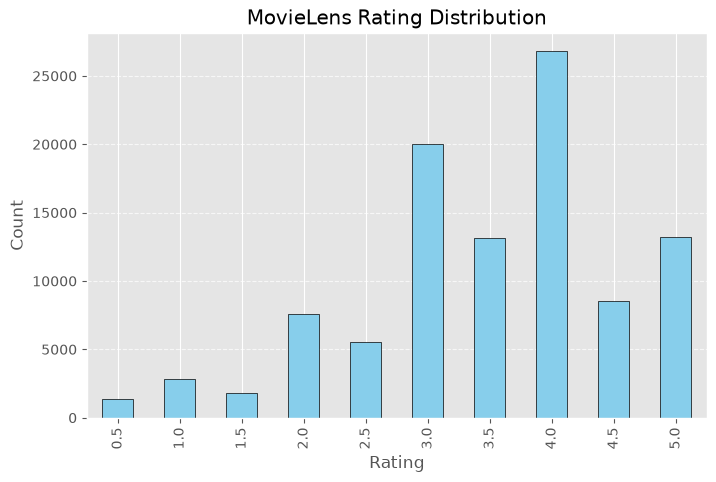

In [5]:
plt.figure(figsize=(8, 5))
movie_ratings_df['rating'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('MovieLens Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3.2 Most-Rated Movies
Let's see which movies have the highest rating volume.

In [6]:
movie_counts = movie_ratings_df.groupby('movieId').size().reset_index(name='count')
top_movies = pd.merge(movie_counts, movies_df, on='movieId')
top_movies = top_movies.sort_values(by='count', ascending=False).head(10)

print("Top 10 Most-Rated Movies:")
print(top_movies[['title', 'count', 'genres']].to_string(index=False))

Top 10 Most-Rated Movies:
                                    title  count                           genres
                      Forrest Gump (1994)    329         Comedy|Drama|Romance|War
         Shawshank Redemption, The (1994)    317                      Crime|Drama
                      Pulp Fiction (1994)    307      Comedy|Crime|Drama|Thriller
         Silence of the Lambs, The (1991)    279            Crime|Horror|Thriller
                       Matrix, The (1999)    278           Action|Sci-Fi|Thriller
Star Wars: Episode IV - A New Hope (1977)    251          Action|Adventure|Sci-Fi
                     Jurassic Park (1993)    238 Action|Adventure|Sci-Fi|Thriller
                        Braveheart (1995)    237                 Action|Drama|War
        Terminator 2: Judgment Day (1991)    224                    Action|Sci-Fi
                  Schindler's List (1993)    220                        Drama|War


### 3.3 Genre Distribution (Movies)

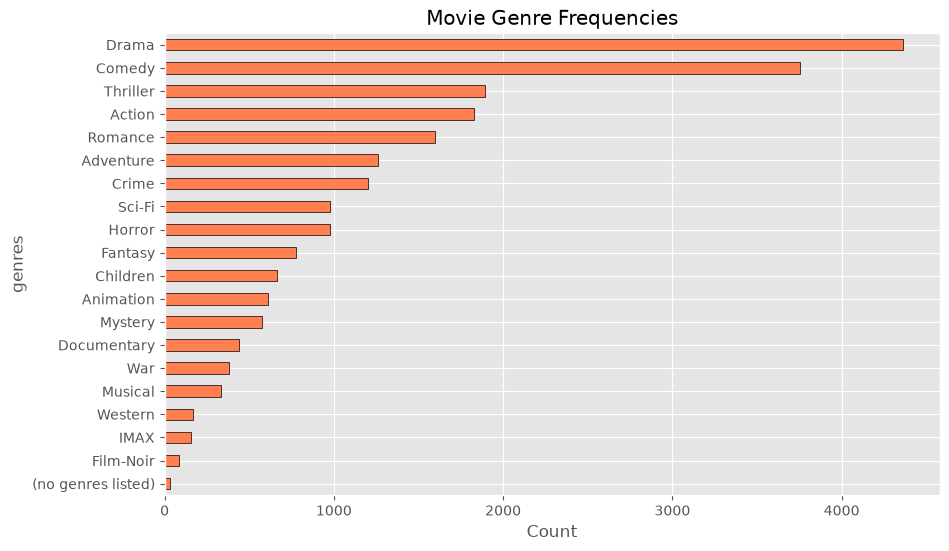

In [7]:
# Split genres and count frequencies
movie_genres_split = movies_df['genres'].str.split('|').explode()
genre_counts = movie_genres_split.value_counts()

plt.figure(figsize=(10, 6))
genre_counts.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Movie Genre Frequencies')
plt.xlabel('Count')
plt.gca().invert_yaxis()  # Put most popular on top
plt.show()

## 4. Exploratory Data Analysis (EDA) — Books

Let's perform the same analysis for our Goodreads book rating subset.

In [8]:
n_users_b = book_ratings_df['user_id'].nunique()
n_books_b = books_df['book_id'].nunique()
n_ratings_b = len(book_ratings_df)
density_b = (n_ratings_b / (n_users_b * n_books_b)) * 100

print("=== GOODREADS STATISTICS ===")
print(f"Number of Users: {n_users_b}")
print(f"Number of Books: {n_books_b}")
print(f"Number of Ratings: {n_ratings_b}")
print(f"Interaction Matrix Density: {density_b:.4f}%")
print(f"Average ratings per user: {book_ratings_df.groupby('user_id').size().mean():.1f}")
print(f"Average ratings per book: {book_ratings_df.groupby('book_id').size().mean():.1f}")

=== GOODREADS STATISTICS ===
Number of Users: 2000
Number of Books: 10000
Number of Ratings: 231949
Interaction Matrix Density: 1.1597%
Average ratings per user: 116.0
Average ratings per book: 25.6


### 4.1 Rating Distribution (Books)

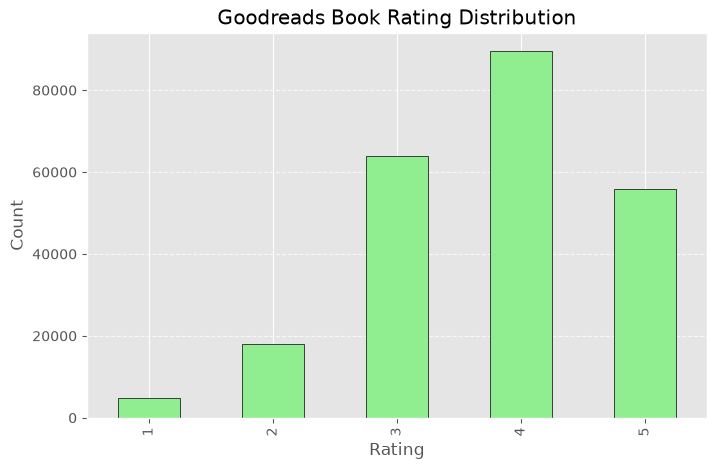

In [9]:
plt.figure(figsize=(8, 5))
book_ratings_df['rating'].value_counts().sort_index().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Goodreads Book Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4.2 Most-Rated Books

In [10]:
book_counts = book_ratings_df.groupby('book_id').size().reset_index(name='count')
top_books = pd.merge(book_counts, books_df, on='book_id')
top_books = top_books.sort_values(by='count', ascending=False).head(10)

print("Top 10 Most-Rated Books:")
print(top_books[['title', 'authors', 'count', 'genres']].to_string(index=False))

Top 10 Most-Rated Books:
                                                      title                                 authors  count                                   genres
                                           The Great Gatsby                     F. Scott Fitzgerald    789                 Classics|Fantasy|Mystery
                                      To Kill a Mockingbird                              Harper Lee    780                                  Fiction
                                     The Catcher in the Rye                           J.D. Salinger    763 Sci-Fi|Mystery|Thriller|Classics|Fantasy
                    The Hunger Games (The Hunger Games, #1)                         Suzanne Collins    750         Classics|Romance|Fantasy|Mystery
   Harry Potter and the Sorcerer's Stone (Harry Potter, #1)             J.K. Rowling, Mary GrandPré    694           Sci-Fi|Romance|Fantasy|Mystery
                     The Da Vinci Code (Robert Langdon, #2)                            

### 4.3 Genre Distribution (Books)

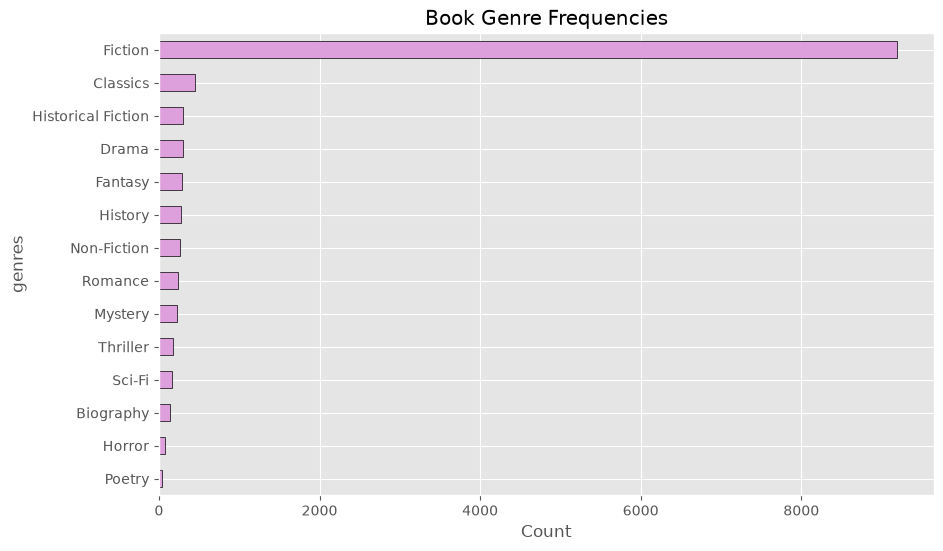

In [11]:
book_genres_split = books_df['genres'].str.split('|').explode()
book_genre_counts = book_genres_split.value_counts()

plt.figure(figsize=(10, 6))
book_genre_counts.plot(kind='barh', color='plum', edgecolor='black')
plt.title('Book Genre Frequencies')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

## 5. Preprocess Data and Apply Split Strategies

Now we run the preprocessing script to clean text, build our `combined_text` features for content search, and create the user-aware split datasets.

In [12]:
# Preprocess items
print("Preprocessing movies and books metadata...")
processed_movies = preprocessor.preprocess_movies(movies_df, movie_tags_df)
processed_books = preprocessor.preprocess_books(books_df)

# Perform splits
print("Performing user-aware splits...")
movie_train, movie_test = preprocessor.split_ratings_user_aware(movie_ratings_df, is_temporal=True)
book_train, book_test = preprocessor.split_ratings_user_aware(book_ratings_df, is_temporal=False)

# Save splits
movie_train.to_csv("../data/processed/movie_ratings_train.csv", index=False)
movie_test.to_csv("../data/processed/movie_ratings_test.csv", index=False)
book_train.to_csv("../data/processed/book_ratings_train.csv", index=False)
book_test.to_csv("../data/processed/book_ratings_test.csv", index=False)

print("Train/Test splits successfully saved to data/processed/")

2026-08-22 13:33:52,510 - INFO - Preprocessing movie dataset...


2026-08-22 13:33:52,692 - INFO - Processed movies saved to C:\Users\ASUS\.gemini\antigravity\scratch\cinematch\data\processed\movies_processed.csv. Shape: (9742, 6)


2026-08-22 13:33:52,694 - INFO - Preprocessing book dataset...


Preprocessing movies and books metadata...


2026-08-22 13:33:53,018 - INFO - Processed books saved to C:\Users\ASUS\.gemini\antigravity\scratch\cinematch\data\processed\books_processed.csv. Shape: (10000, 27)


...

Performing user-aware splits...


2026-08-22 13:33:53,238 - INFO - Split complete. Train shape: (80896, 4), Test shape: (19940, 4)


2026-08-22 13:33:53,243 - INFO - Splitting ratings (user-aware, temporal=False)...


2026-08-22 13:33:54,238 - INFO - Split complete. Train shape: (186363, 3), Test shape: (45586, 3)


Train/Test splits successfully saved to data/processed/


### 5.1 Content Feature Inspect
Let's print a sample of the text representations generated for our TF-IDF model.

In [13]:
print("=== MOVIE COMBINED TEXT SAMPLE ===")
for i, row in processed_movies.head(3).iterrows():
    print(f"Title: {row['title']}")
    print(f"Combined Feature: {row['combined_text']}\n")
    
print("=== BOOK COMBINED TEXT SAMPLE ===")
for i, row in processed_books.head(3).iterrows():
    print(f"Title: {row['title']}")
    print(f"Combined Feature: {row['combined_text']}\n")

=== MOVIE COMBINED TEXT SAMPLE ===
Title: Toy Story (1995)
Combined Feature: toy story 1995 adventure animation children comedy fantasy pixar fun

Title: Jumanji (1995)
Combined Feature: jumanji 1995 adventure children fantasy game robin williams magic board game fantasy

Title: Grumpier Old Men (1995)
Combined Feature: grumpier old men 1995 comedy romance old moldy

=== BOOK COMBINED TEXT SAMPLE ===
Title: The Hunger Games (The Hunger Games, #1)
Combined Feature: the hunger games the hunger games 1 suzanne collins classics romance fantasy mystery

Title: Harry Potter and the Sorcerer's Stone (Harry Potter, #1)
Combined Feature: harry potter and the sorcerers stone harry potter 1 jk rowling mary grandpr sci-fi romance fantasy mystery

Title: Twilight (Twilight, #1)
Combined Feature: twilight twilight 1 stephenie meyer classics fantasy mystery



### 5.2 Verification of Split Properties
For collaborative filtering models (like Item-Item or Matrix Factorization), it is vital to check if test users exist in the training set (to avoid the absolute cold-start user problem during model evaluation, which is treated separately).

In [14]:
train_users = set(movie_train['userId'])
test_users = set(movie_test['userId'])
unseen_users = test_users - train_users

print(f"Total training users: {len(train_users)}")
print(f"Total test users: {len(test_users)}")
print(f"Test users missing from training set: {len(unseen_users)}")

# Check item coverage in train vs test
train_items = set(movie_train['movieId'])
test_items = set(movie_test['movieId'])
unseen_items = test_items - train_items
print(f"Total training items: {len(train_items)}")
print(f"Total test items: {len(test_items)}")
print(f"Test items missing from training set (cold items): {len(unseen_items)}")

Total training users: 610
Total test users: 610
Test users missing from training set: 0
Total training items: 8247
Total test items: 6244
Test items missing from training set (cold items): 1477


Excellent! Stage 1 is fully complete. We have loaded, analyzed, preprocessed, and saved train/test partitions using a user-aware temporal/random split. We are ready to proceed to Stage 2: Content-Based Recommender!